Reissner Mindlin Plate : Modal Analysis with Fenicsx and Thermomechanics residual stress due to a real heatmap
=================
This model will help us to understand model of thermo-elastic modal analysis.

In [102]:
import numpy as np
import ufl
import basix

from mpi4py import MPI
from dolfinx import fem, io , plot
import dolfinx.fem.petsc
from dolfinx.fem import Constant, dirichletbc, Function, functionspace, locate_dofs_topological
import dolfinx.mesh as mesh
from dolfinx.io import XDMFFile

In [103]:
from IPython.core.magic import register_cell_magic
from IPython import get_ipython


@register_cell_magic
def skip(line, cell):
    """Commande magique pour ignorer une cellule."""
    if line.strip().lower() == 'true':
        print("⏭️ Cellule ignorée.")
        return # On quitte sans exécuter le code en dessous
    
    # Sinon, on exécute normalement le contenu de la cellule
    get_ipython().run_cell(cell)

In [104]:
L  = 0.30 # Longueur de la plaque
W_dim = 0.24 # Largeur de la plaque
Nx = 200 # Nombre de subdivision de la plaque
Ny = 200
domain = dolfinx.mesh.create_rectangle(
    MPI.COMM_WORLD, [[0, 0], [L, W_dim]], [Nx, Ny] , cell_type=dolfinx.mesh.CellType.quadrilateral
) # Création du "mesh" de la plaque elle nous servira tous le long du programme pour appeler notre forme

gdim = domain.geometry.dim

# material parameters
thick = 0.0010 # épaisseur de la plaque
E = 200.08e9 # Module de Young du matériaus [Pa]
nu = 0.30 # Coef de poisson du matériau
rho = 7777.0 # Masse volumique [kg/m3]
alpha = fem.Constant(domain, 12.0e-6) # Coefficient de dilatation thermique [1/K]

lmbd = fem.Constant(domain , E * nu / ((1 + nu)*(1-2*nu)))
mu = fem.Constant(domain , E / (2*(1+nu)))

Thermical problem of the plates
=================

Based on : [Linear thermoelasticity (weak coupling)](https://bleyerj.github.io/comet-fenicsx/tours/linear_problems/thermoelasticity_weak/thermoelasticity_weak.html)

We consider the case of a rectangular 2D domain of dimensions $L\times H$. The top side is subjected to a ponctual temperature increase of $\Delta T = +400^{\circ}C$ while the bottom and lateral boundaries remain at the initial temperature $T_0$.

Pour l'estimation de la heat map pour ce modéle on utilise un modéle émélents finis. dont la forme Forte correspond à çà :

$T + \alpha \Delta T = T_{brut} $

In [105]:
import scipy
from scipy.interpolate import griddata

map = scipy.io.loadmat('map_chaleur/bas_droite_sort.mat')

frame = np.array(map['Frame'])

### Plaque : bas_droite_sort.mat
p_00_plaque = np.array([63,52])
p_10_plaque = np.array([74,437])
p_11_plaque = np.array([554,424])
p_01_plaque = np.array([545,34])

### Plaque : central_bas.mat
# p_00_plaque = np.array([42,56])
# p_10_plaque = np.array([55,468])
# p_11_plaque = np.array([575,460])
# p_01_plaque = np.array([570,80])

### Plaque : bas_gauche.mat
# p_00_plaque = np.array([46,58])
# p_10_plaque = np.array([57,468])
# p_11_plaque = np.array([570,457])
# p_01_plaque = np.array([563,44])

def var_plaque(ksi) :
    x = (1-ksi[0])*(1-ksi[1])*p_00_plaque + ksi[0]*(1-ksi[1])*p_10_plaque + ksi[0]*ksi[1]*p_11_plaque + (1-ksi[0])*ksi[1]*p_01_plaque
    return x

def heatmap_real(frame , nx , ny) :
    x = np.zeros((nx,ny,2))
    for i in range(nx) :
        for j in range(ny) :
            ksi = np.array([i/(nx-1),j/(ny-1)])
            x[i,j] = var_plaque(ksi)
    values = frame[x[:,:,1].astype(int), x[:,:,0].astype(int)]
    return values

heatmap = heatmap_real(frame , Nx , Ny)

heatmap = heatmap - np.min(heatmap)  

x_n = np.linspace(0, L, Nx)
y_n = np.linspace(0, W_dim, Ny)
X_heatmap, Y_heatmap = np.meshgrid(x_n, y_n , indexing='ij')

VT = fem.functionspace(domain, ("Lagrange", 1)) # Espace de fonctions pour la température
Delta_T = fem.Function(VT) # Fonction pour stocker les valeurs de la température

coord_fenics = VT.tabulate_dof_coordinates()
x_fenics = coord_fenics[:, 0]
y_fenics = coord_fenics[:, 1]



val_interp = griddata(
    points=(X_heatmap.flatten(), Y_heatmap.flatten()),
    values=heatmap.T.flatten(),
    xi=(x_fenics, y_fenics) ,
    method='cubic'
)

val_interp_proche = griddata(
    points=(X_heatmap.flatten(), Y_heatmap.flatten()),
    values=heatmap.flatten(),
    xi=(x_fenics, y_fenics),
    method='nearest'
)

masque_trous = np.isnan(val_interp)

val_interp[masque_trous] = val_interp_proche[masque_trous]

Delta_T.x.array[:] = val_interp

alpha_lis = fem.Constant(domain, 5.0e-6) 

T_trial = ufl.TrialFunction(VT)
T_test = ufl.TestFunction(VT)

a_lissage = ( T_trial * T_test + alpha_lis * ufl.inner(ufl.grad(T_trial), ufl.grad(T_test))) * ufl.dx
L_lissage = Delta_T * T_test * ufl.dx

problem_lissage = fem.petsc.LinearProblem(a_lissage, L_lissage, bcs=[], petsc_options={"ksp_type": "cg", "pc_type": "jacobi"} , petsc_options_prefix="lissage_")
Delta_T = problem_lissage.solve()

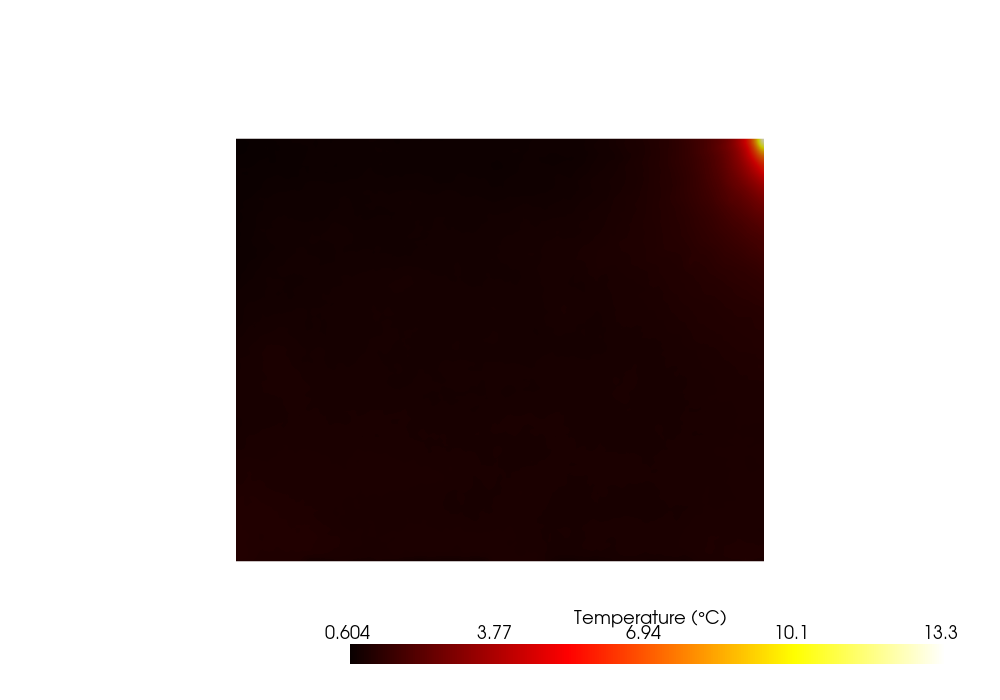

In [106]:
import pyvista

pyvista.set_jupyter_backend("static")

T_topology, T_cell_types, T_geometry = plot.vtk_mesh(VT)
T_grid = pyvista.UnstructuredGrid(T_topology, T_cell_types, T_geometry)
T_grid.point_data["Temperature"] = Delta_T.x.array
T_grid.set_active_scalars("Temperature")

plotter = pyvista.Plotter(window_size=[1000, 700])
plotter.add_mesh(
    T_grid, 
    scalars="Temperature", 
    cmap="hot",        # "coolwarm" (Bleu -> Rouge), "jet" ou "hot" sont excellents pour la thermique
    show_edges=False,        # Affiche les lignes du maillage (mettez False si c'est trop dense)
    edge_color="grey",      # Adoucit la couleur du maillage
    scalar_bar_args={"title": "Temperature (°C)", "color": "black"} 
)  
plotter.view_xy()
plotter.zoom_camera(1)
plotter.show()

## Termo-Mechanics problem

In [107]:
# Matrice des mouvements membranaires
A = fem.Constant(domain, E * thick / (1 - nu**2))
# bending stiffness
D = fem.Constant(domain, E * thick**3 / (1 - nu**2) / 12.0)
# shear stiffness
F = fem.Constant(domain, E / 2 / (1 + nu) * thick * 5.0 / 6.0)
# Inertilal constant
M = fem.Constant(domain , rho * thick)

def membrane_strain(u):
    (psi , w, theta) = ufl.split(u)
    return ufl.as_vector(
        [psi[0].dx(0), psi[1].dx(1), psi[0].dx(1) + psi[1].dx(0)]
    )

def curvature(u):
    (psi , w, theta) = ufl.split(u)
    return ufl.as_vector(
        [theta[0].dx(0), theta[1].dx(1), theta[0].dx(1) + theta[1].dx(0)]
    )

# def shear_strain(u):
#     (psi , w, theta) = ufl.split(u)
#     return ufl.grad(w) - theta

def shear_strain(u):
    (psi , w, theta) = ufl.split(u)
    return ufl.as_vector([w.dx(0) + theta[0], w.dx(1) + theta[1]])

def membrane_force(u):
    AA = ufl.as_matrix([[A, nu * A, 0], [nu * A, A, 0], [0, 0, A * (1 - nu) / 2.0]])
    return ufl.dot(AA, membrane_strain(u))

def bending_moment(u):
    DD = ufl.as_matrix([[D, nu * D, 0], [nu * D, D, 0], [0, 0, D * (1 - nu) / 2.0]])
    return ufl.dot(DD, curvature(u))

def inertial(u) :
    MM = ufl.as_matrix([[M,0,0, 0, 0],[0,M,0, 0, 0],[0,0,M, 0, 0], [0,0,0, M*thick**2/12, 0], [0,0,0, 0, M*thick**2/12]])
    return ufl.dot(MM, u)

def shear_force(u):
    FF = F * ufl.Identity(2)
    return FF * shear_strain(u)

def eps(u) : 
    (psi , w, theta) = ufl.split(u)

    return ufl.sym(ufl.grad(psi))

# def sigma_th(u) :
#     I_voight = ufl.as_vector([1, 1, 0])
#     return( lmbd * ufl.tr(eps(u))- alpha * ( 3*lmbd + 2*mu ) * Delta_T
#     ) * I_voight + 2*mu * membrane_strain(u)

def sigma_th(u) :
    I_voigt = ufl.as_vector([1.0, 1.0, 0.0]) 
    # Effort thermique pour les contraintes planes 
    facteur = (E * alpha * Delta_T) / (1.0 - nu)
    return facteur * thick * I_voigt


On crée un vecteur avec 1 déplacement vertical et 2 rotation autour de la courbure :

$P_e = \begin{bmatrix} \psi_1  \\ \psi_2 \end{bmatrix} $

$U_e = U_3$

$T_e = \begin{bmatrix} \phi_1  \\ \phi_2 \end{bmatrix} $

In [108]:
Pe = basix.ufl.element("Q", domain.basix_cell(), 1, shape=(2,))
Ue = basix.ufl.element("Q", domain.basix_cell(), 1)
Te = basix.ufl.element("Q", domain.basix_cell(), 1, shape=(2,))
V = fem.functionspace(domain, basix.ufl.mixed_element([Pe , Ue, Te]))

In [109]:
u_th = fem.Function(V, name="Deplacement")
u__th = ufl.TestFunction(V)
(psi__th , w__th , theta__th) = ufl.split(u__th)
du_th = ufl.TrialFunction(V)
(dpsi__th ,dw__th , dtheta__th) = ufl.split(du_th)

In [110]:
dx = ufl.Measure("dx", domain=domain)

W = (
    ufl.inner(membrane_force(du_th) , membrane_strain(u__th)) 
    + ufl.inner(bending_moment(du_th), curvature(u__th))
    + ufl.inner(shear_force(du_th), shear_strain(u__th))
    - ufl.inner(sigma_th(du_th ) , membrane_strain(u__th))
) * dx

a_th = ufl.lhs(W)
L_th = ufl.rhs(W)

### Conditions aux Limites

On choisi d'encastrer un bords de notre probléme pour voir les variations de déformation

In [111]:

def encastrement_00(x):
    return np.logical_and(np.isclose(x[0], 0.0), np.isclose(x[1], 0.0))

def appui_plan(x):
    return np.logical_and(np.isclose(x[0], L), np.isclose(x[1], 0.0))

V_phi, _ = V.sub(0).collapse()

# 2. On utilise V_phi au lieu de Pe pour localiser les DOFs
bc_dofs = fem.locate_dofs_geometrical((V.sub(0), V_phi), encastrement_00)

# 3. On crée la valeur de la condition (un vecteur nul) sur le bon espace V_phi
phi00 = fem.Function(V_phi, name="Phi_00")
# (Note : phi00 est initialisée à [0.0, 0.0] par défaut)

# 4. On crée la condition aux limites (Attention au 'c' minuscule et au 3ème argument)
bc_phi = fem.dirichletbc(phi00, bc_dofs, V.sub(0))

# APPUI PLAN 0 0 
V_psi_y, _ = V.sub(0).sub(1).collapse() 

dofs_psi_y_2 = fem.locate_dofs_geometrical((V.sub(0).sub(1), V_psi_y), appui_plan)

bc_appui = fem.dirichletbc(fem.Constant(domain, 0.0), dofs_psi_y_2[0], V.sub(0).sub(1))

# appui plan w

V_w , _ = V.sub(1).collapse()
dofs_w_00 = fem.locate_dofs_geometrical((V.sub(1), V_w), appui_plan)
bc_appui_w_00 = fem.dirichletbc(fem.Constant(domain, 0.0), dofs_w_00[0], V.sub(1))

V_w , _ = V.sub(1).collapse()
dofs_w_LW = fem.locate_dofs_geometrical((V.sub(1), V_w), encastrement_00)
bc_appui_w_LW = fem.dirichletbc(fem.Constant(domain, 0.0), dofs_w_LW[0], V.sub(1))

bcs_Tm = [bc_phi, bc_appui, bc_appui_w_LW, bc_appui_w_00]

Résolution du probléme Thermo-méca

In [112]:
from dolfinx.fem.petsc import LinearProblem

problem = LinearProblem(
    a_th, L_th, u=u_th, bcs=bcs_Tm, petsc_options={"ksp_type": "preonly", "pc_type": "lu"}, petsc_options_prefix="Plate"
)
problem.solve()

Coefficient(FunctionSpace(Mesh(blocked element (Basix element (P, quadrilateral, 1, gll_warped, unset, False, float64, []), (2,)), 4), mixed element (blocked element (Basix element (P, quadrilateral, 1, gll_warped, unset, False, float64, []), (2,)), Basix element (P, quadrilateral, 1, gll_warped, unset, False, float64, []), blocked element (Basix element (P, quadrilateral, 1, gll_warped, unset, False, float64, []), (2,)))), 50)

Affichage

Déformation totale (eps_total) :  sym(grad([Deplacement[0], Deplacement[1]]))


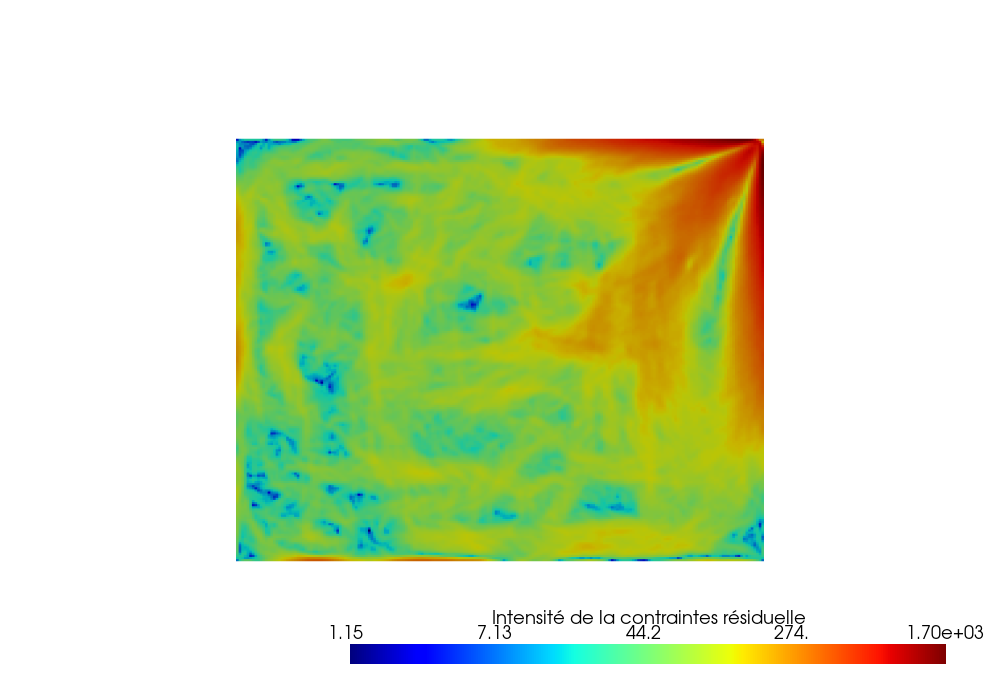

In [113]:
import pyvista
import numpy as np
from dolfinx import plot, fem
import ufl

pyvista.set_jupyter_backend('static')

# --- 1. Calcul de la déformation MÉCANIQUE pure (Strain) ---
# On extrait le mouvement planaire (psi)
(psi, w, theta) = ufl.split(u_th)

# Déformation totale (Gradient du déplacement planaire)
eps_total = ufl.sym(ufl.grad(psi))

print("Déformation totale (eps_total) : ", eps_total)

# Déformation thermique pure (Matrice 2x2 diagonale)
eps_thermique = alpha * Delta_T * ufl.Identity(2)

# Déformation mécanique 
eps_mecanique = eps_total - eps_thermique

# On calcule une valeur scalaire représentative : la "Norme" de cette déformation
# (Equivalent d'une intensité de déformation de Von Mises)

def Voight(eps):
    return ufl.as_vector([eps[0,0], eps[1,1], 2*eps[0,1]]) # Conversion de la notation tensorielle à la notation de Voigt (tau_xy = 2*eps_xy)

def Prestress_Tensor(eps_mecanique):
    # a. Calcul des déformations avec votre fonction (u_solution a bien 3 composantes)
    eps = Voight(eps_mecanique)
    
    # b. Matrice de Hooke (Attention : les termes croisés sont positifs ! j'ai corrigé vos -E/nu)
    facteur = E / (1.0 - nu**2)
    C = facteur * ufl.as_matrix([
        [1.0,  nu,   0.0], 
        [ nu, 1.0,   0.0], 
        [0.0, 0.0, (1.0 - nu) / 2.0]
    ])
    
    # c. Calcul des contraintes (Vecteur de Voigt 3x1)
    sig_voigt = ufl.dot(C, eps)
    
    # d. Création du tenseur 2x2 physique des efforts (en multipliant par l'épaisseur)
    return thick * ufl.as_matrix([
        [sig_voigt[0], sig_voigt[2]], # [sigma_xx,  tau_xy]
        [sig_voigt[2], sig_voigt[1]]  # [tau_xy,  sigma_yy]
    ])
sig = Prestress_Tensor(eps_mecanique)
norme_sig_mech = ufl.sqrt(ufl.inner(sig, sig))
norme_eps_mech = ufl.sqrt(ufl.inner(eps_mecanique, eps_mecanique))

# --- 2. Projection sur un espace visualisable ---
# On crée un espace de fonctions scalaires (DG 0 = une valeur constante par petit carré du maillage)
V_strain = fem.functionspace(domain, ("DG", 0))
expr = fem.Expression(
    norme_sig_mech, 
    V_strain.element.interpolation_points, 
    dtype=dolfinx.default_scalar_type
)

# On crée la fonction et on l'évalue (Interpolation)
strain_field = fem.Function(V_strain)
strain_field.interpolate(expr)

# --- 3. Création de la grille PyVista ---
topology, cell_types, geometry = plot.vtk_mesh(domain)
grid = pyvista.UnstructuredGrid(topology, cell_types, geometry)

# On injecte nos valeurs de déformation
grid.cell_data["Mechanical_Strain"] = strain_field.x.array
grid.set_active_scalars("Mechanical_Strain")

# --- 4. Affichage en Carte de Chaleur ---
plotter = pyvista.Plotter(window_size=[1000, 700])
plotter.set_background("white")

plotter.add_mesh(
    grid, 
    scalars="Mechanical_Strain", 
    cmap="jet",
    show_edges=False, 
    edge_color="gray",
    scalar_bar_args={"title": "Intensité de la contraintes résiduelle", "color": "black"}, # Ajoute la barre de légende
    log_scale=1 
)

plotter.view_xy()
plotter.show()

Governor Equation of mechanical problem
===============

First of all, this work is base on Jeremie Bleyer's work which can be found with this link : [Fenicsx Tour : Reissner-Mindlin plates ](https://bleyerj.github.io/comet-fenicsx/intro/plates/plates.html)

Generalized strain
---------------

- Mouvement Membranaire : $ \omega = \nabla^S \psi $
- Courbure : $ \chi = \nabla^S \phi  $
- Déformation de cisaillement : $ \gamma = \nabla u - \phi $

Generalized stresses
----------------

- Moment lié à la courbure : $ \textbf{M} $
- Force de cisaillement : $ \textbf{V} $ 

Formulation Forte 
----------------

 - $ V_{ \beta , \beta } = M \ddot U_3 $
 - $ M_{ \alpha \beta , \beta } - V_\alpha = I \ddot \phi _\alpha $




Implentation des paramétres de la plaque étudié

## Création des des matrices et des constantes :
- Matrice des Movements Membranaire

$$
\mathbf{A} = A \begin{bmatrix}
1 & \nu & 0 \\
\nu & 1 & 0 \\
0 & 0 & \frac{1-\nu}{2}
\end{bmatrix} 
\quad \text{avec} \quad A = \frac{E \times h}{(1-\nu^2)}

$$

- Matrice des Moments
$$
\mathbf{D} = D \begin{bmatrix}
1 & \nu & 0 \\
\nu & 1 & 0 \\
0 & 0 & \frac{1-\nu}{2}
\end{bmatrix} 
\quad \text{avec} \quad 
D = \frac{E \times h^3}{12(1-\nu^2)}
$$
- Constante des efforts de cisaillement
$$
F = \frac{5}{6} \times \frac{E \times h}{2(1 + \nu)}
$$
- Matrice de Masse
$$
\mathbf{M} = M \begin{bmatrix}
1 & 0 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 & 0 \\
0 & 0 & 1 & 0 & 0 \\
0 & 0 & 0 & \frac{h^2}{12} & 0 \\
0 & 0 & 0 & 0 & \frac{h^2}{12}
\end{bmatrix}
\quad \text{avec} \quad
M = \rho h
$$

- Matrice des précontraintes

$$
\begin{aligned}
\underline{\underline{L}} &= \int_h \underline{\underline{\tilde{\sigma}}}(z) z^2 \, dz \\
\underline{\underline{J}} &= \int_h \underline{\underline{\tilde{\sigma}}}(z) z \, dz \\
\underline{\underline{P}} &= \int_h \underline{\underline{\tilde{\sigma}}}(z) \, dz 
\end{aligned}
\qquad \text{donc} \qquad
\underset{\approx}{\Omega} = \begin{bmatrix}
\underline{\underline{P}} &0&0 & \underline{\underline{J}} & 0 \\
0&\underline{\underline{P}} &0 & 0 & \underline{\underline{J}} \\
0&0 &\underline{\underline{P}} & 0 & 0 \\
\underline{\underline{J}}&0 & 0 & \underline{\underline{L}} & 0 \\
0&\underline{\underline{J}} &0 & 0 & \underline{\underline{L}}
\end{bmatrix}
$$

On crée un vecteur avec 1 déplacement vertical et 2 rotation autour de la courbure :

$P_e = \begin{bmatrix} \psi_1  \\ \psi_2 \end{bmatrix} $

$U_e = U_3$

$T_e = \begin{bmatrix} \phi_1  \\ \phi_2 \end{bmatrix} $

In [114]:
# Matrice des mouvements membranaires
A = fem.Constant(domain, E * thick / (1 - nu**2))
# bending stiffness
D = fem.Constant(domain, E * thick**3 / (1 - nu**2) / 12.0)
# shear stiffness
F = fem.Constant(domain, E / 2 / (1 + nu) * thick * 5.0 / 6.0)
# Inertilal constant
M = fem.Constant(domain , rho * thick)
# Acousto-Elastic Constants

sig_th = -(E * alpha * Delta_T) / (1-nu) # Pre-stress in the plate [Pa]
P = sig_th * thick

L_m = sig_th * thick**3 / 12.0

def membrane_strain(u):
    (psi , w, theta) = ufl.split(u)
    return ufl.as_vector(
        [psi[0].dx(0), psi[1].dx(1), psi[0].dx(1) + psi[1].dx(0)]
    )

def curvature(u):
    (psi , w, theta) = ufl.split(u)
    return ufl.as_vector(
        [theta[0].dx(0), theta[1].dx(1), theta[0].dx(1) + theta[1].dx(0)]
    )

# def shear_strain(u):
#     (psi , w, theta) = ufl.split(u)
#     return ufl.grad(w) - theta


def shear_strain(u):
    (psi , w, theta) = ufl.split(u)
    return ufl.as_vector([w.dx(0) - theta[0], w.dx(1) - theta[1]])

def membrane_force(u):
    AA = ufl.as_matrix([[A, nu * A, 0], [nu * A, A, 0], [0, 0, A * (1 - nu) / 2.0]])
    return ufl.dot(AA, membrane_strain(u))

def bending_moment(u):
    DD = ufl.as_matrix([[D, nu * D, 0], [nu * D, D, 0], [0, 0, D * (1 - nu) / 2.0]])
    return ufl.dot(DD, curvature(u))

def inertial(u) :
    MM = ufl.as_matrix([[M,0,0, 0, 0],[0,M,0, 0, 0],[0,0,M, 0, 0], [0,0,0, M*thick**2/12, 0], [0,0,0, 0, M*thick**2/12]])
    return ufl.dot(MM, u)


def shear_force(u):
    return F * shear_strain(u)

def Voight(eps):
    return ufl.as_vector([eps[0,0], eps[1,1], 2*eps[0,1]]) # Conversion de la notation tensorielle à la notation de Voigt (tau_xy = 2*eps_xy)

# 1. Fonction pour générer le Tenseur 2x2 de précontrainte
# Pensez à passer la solution statique COMPLÈTE issue de votre premier calcul (ex: u_statique)
def Prestress_Tensor(eps_mecanique):
    # a. Calcul des déformations avec votre fonction (u_solution a bien 3 composantes)
    eps = Voight(eps_mecanique)
    
    # b. Matrice de Hooke (Attention : les termes croisés sont positifs ! j'ai corrigé vos -E/nu)
    facteur = E / (1.0 - nu**2)
    C = facteur * ufl.as_matrix([
        [1.0,  nu,   0.0], 
        [ nu, 1.0,   0.0], 
        [0.0, 0.0, (1.0 - nu) / 2.0]
    ])
    
    # c. Calcul des contraintes (Vecteur de Voigt 3x1)
    sig_voigt = ufl.dot(C, eps)
    
    # d. Création du tenseur 2x2 physique des efforts (en multipliant par l'épaisseur)
    return thick * ufl.as_matrix([
        [sig_voigt[0], sig_voigt[2]], # [sigma_xx,  tau_xy]
        [sig_voigt[2], sig_voigt[1]]  # [tau_xy,  sigma_yy]
    ])

# 2. On évalue ce tenseur UNE SEULE FOIS avant d'assembler la matrice
# Remplacez 'u_statique' par le vrai nom de votre variable qui contient le résultat du calcul linéaire
N_prestress = Prestress_Tensor(eps_mecanique) 

# 3. Fonctions d'énergie corrigées
def residual_stress_shear(u, v): 
    (dpsi, dw, dtheta) = ufl.split(u)
    (psi_, w_, theta_) = ufl.split(v)
    
    # On utilise "inner" et on place la matrice 2x2 N_prestress au milieu des gradients
    return ufl.inner(ufl.grad(dw), N_prestress * ufl.grad(w_))

def residual_stress_membrane(u, v):
    (dpsi, dw, dtheta) = ufl.split(u)
    (psi_, w_, theta_) = ufl.split(v)
    return ufl.inner(ufl.grad(dpsi), N_prestress * ufl.grad(psi_))

def residual_stress_bending(u, v):
    (dpsi, dw, dtheta) = ufl.split(u)
    (psi_, w_, theta_) = ufl.split(v)
    
    # Pour la flexion, il faut multiplier par thick**3 / 12 (au lieu de thick)
    # On divise donc N_prestress par l'épaisseur et on multiplie par le moment quadratique
    M_prestress = N_prestress * (thick**2 / 12.0)
    return ufl.inner(ufl.grad(dtheta), M_prestress * ufl.grad(theta_))

In [115]:
Pe = basix.ufl.element("Q", domain.basix_cell(), 1, shape=(2,))
Ue = basix.ufl.element("Q", domain.basix_cell(), 2)
Te = basix.ufl.element("Q", domain.basix_cell(), 1, shape=(2,))
V = fem.functionspace(domain, basix.ufl.mixed_element([Pe , Ue, Te]))

Création des fonctions pour la formulation faible 

In [116]:
u = fem.Function(V, name="Unknown")
u_ = ufl.TestFunction(V)
(psi_ , w_, theta_) = ufl.split(u_)
du = ufl.TrialFunction(V)
(dpsi ,dw , dtheta) = ufl.split(du)

Définition de la formulation Faible

In [117]:
dx = ufl.Measure("dx", domain=domain)
L = fem.Constant(domain, 0.0) * w_ * dx

# On définit la forme de raideur K complète
a = (
    ufl.inner(membrane_force(du) , membrane_strain(u_)) 
    + ufl.inner(bending_moment(du), curvature(u_))
    + ufl.inner(shear_force(du), shear_strain(u_))
    + residual_stress_bending(du, u_) 
    + residual_stress_shear(du, u_)
    + residual_stress_membrane(du, u_)
) * dx

a_static = ufl.lhs(a)
L_static = ufl.rhs(a) + fem.Constant(domain, 0.0) * w_ * dx

Définition des conditions aux limites de la plaque

In [118]:
def border(x):
    return np.logical_or(np.isclose(x[0], 0), np.isclose(x[0], 0))

facet_dim = 1
clamped_facets = dolfinx.mesh.locate_entities_boundary(domain, facet_dim, border)
clamped_dofs = fem.locate_dofs_topological(V, facet_dim, clamped_facets)

u0 = fem.Function(V)
bcs = []

Résolution du probléme Linéaire : Optionnel

In [119]:
%%skip True

from dolfinx.fem.petsc import LinearProblem

problem = LinearProblem(
    a_static, L_static, u=u, bcs=bcs, petsc_options={"ksp_type": "preonly", "pc_type": "lu"}, petsc_options_prefix="Plate"
)
problem.solve()

⏭️ Cellule ignorée.


Affichage de la solution du probléme Linéaire

In [120]:
%%skip True

import pyvista
import numpy as np
from dolfinx import plot

pyvista.set_jupyter_backend('static') # ou 'trame' selon ce qui marche le mieux chez vous

# --- 1. Extraction des mouvements membranaires ---
u_m = u.sub(0).collapse()
Vm = u_m.function_space

# --- 2. Création de la grille PyVista ---
um_topology, um_cell_types, um_geometry = plot.vtk_mesh(Vm)
um_grid = pyvista.UnstructuredGrid(um_topology, um_cell_types, um_geometry)

# --- 3. Calcul de l'amplitude du déplacement (Norme) ---
# On récupère le tableau plat et on le remet en colonnes [ux, uy]
um_values_2D = u_m.x.array.reshape(-1, 2)

# On calcule la norme mathématique : sqrt(ux^2 + uy^2)
magnitude = np.linalg.norm(um_values_2D, axis=1)

# On injecte cette valeur SCALAIRE dans PyVista
um_grid.point_data["Magnitude"] = magnitude
um_grid.set_active_scalars("Magnitude")

# --- 4. Affichage en Carte de Chaleur ---
plotter = pyvista.Plotter(window_size=[1000, 700])
plotter.set_background("white")

plotter.add_mesh(
    um_grid, 
    scalars="Magnitude", 
    cmap="jet",             # "jet" (bleu à rouge) est très visuel pour les déplacements
    show_edges=True,        # Affiche le maillage
    edge_color="gray",
    scalar_bar_args={"title": "Norme du deplacement plan [m]", "color": "black"}
)

plotter.view_xy()
plotter.show()

⏭️ Cellule ignorée.


Analyse Modale du probléme 
-------
Dans cette partie nous allons résoudre l'équation :

$ KV - \lambda MV = 0 $

On récupérera les fréquences propres gràce à $ \lambda = \omega ^2 $ et $ \omega = 2 \pi f $

Définition de la Matrice de masse en formulation faible et assemblage des matrices de Masse et de raideur

In [121]:
m_form =  ufl.dot(inertial(u_), du) * dx

K = fem.petsc.assemble_matrix(fem.form(a), bcs = [])
K.assemble()
M = fem.petsc.assemble_matrix(fem.form(m_form), bcs = [])
M.assemble()

Solver du probléme aux modes propres

In [122]:
from petsc4py import PETSc
from slepc4py import SLEPc

N_eig = 15
eigensolver = SLEPc.EPS().create(MPI.COMM_WORLD)
eigensolver.setDimensions(N_eig)
eigensolver.setProblemType(SLEPc.EPS.ProblemType.GHEP)
st = SLEPc.ST().create(MPI.COMM_WORLD)
st.setType(SLEPc.ST.Type.SINVERT)
st.setShift(0.1)
st.setFromOptions()
eigensolver.setST(st)
eigensolver.setOperators(K, M)
eigensolver.setFromOptions()

# Compute eigenvalue-eigenvector pairs
eigensolver.solve()
evs = eigensolver.getConverged()
vr, vi = K.getVecs()
u_output = Function(V)
u_output.name = "Eigenvector"
evs = eigensolver.getConverged()
print(f"Nombre de modes convergés : {evs}")

Nombre de modes convergés : 15


Trouvé l'ensemble des solutions :

In [123]:
import pyvista
import numpy as np

pyvista.set_jupyter_backend('trame') # ou 'trame' selon ce qui marche le mieux chez vous

# Choix du mode à afficher (ex: 3, 4, 5... pour sauter les modes de corps rigide)
mode_cible = 6

# Vérification que le mode demandé a bien été calculé
if mode_cible < evs:
    # 1. Récupération de la valeur propre et calcul de la fréquence
    l = eigensolver.getEigenpair(mode_cible, vr, vi)
    freq = np.sqrt(max(0, l.real)) / (2 * np.pi)
    
    # 2. Extraction sécurisée de la déflexion w
    u_output.x.array[:] = vr.getArray()
    u_output.x.scatter_forward()
    w_mode = u_output.sub(1).collapse()
    
    # 3. Création du maillage PyVista
    topology, cell_types, geometry = plot.vtk_mesh(w_mode.function_space)
    grid = pyvista.UnstructuredGrid(topology, cell_types, geometry)
    
    # Normalisation pour l'affichage (max amplitude = 1)
    w_array = w_mode.x.array
    grid.point_data["Amplitude"] = w_array / np.max(np.abs(w_array))
    warped = grid.warp_by_scalar("Amplitude", factor=0.05)
    
    # 4. Configuration et affichage de la fenêtre unique
    plotter = pyvista.Plotter(window_size=[1000, 700])
    plotter.set_background("white")
    plotter.add_text(
                    f"Mode {mode_cible} : {freq:.1f} Hz", 
                    position="lower_edge", 
                    font_size=14, 
                    color="black"
                    )
    plotter.add_mesh(warped, cmap="jet", show_scalar_bar=False , lighting=False)
    plotter.add_mesh(warped.extract_all_edges(), color="black", opacity=0.1)
    plotter.view_xy()
    plotter.enable_parallel_projection()
    plotter.show()
else:
    print(f"Le mode {mode_cible} n'a pas été calculé. Modes convergés : {evs}")

Widget(value='<iframe src="http://localhost:41357/index.html?ui=P_0x7e2e31538f90_18&reconnect=auto" class="pyv…

Affichage des différents mode :
----


In [124]:
import numpy as np
# Vérification que le mode demandé a bien été calculé

mode = np.linspace(0, evs, evs, dtype=int)
freq_ha = []
l_m = []

# 1. Récupération de la valeur propre et calcul de la fréquence
for m in mode[:-1] :
    l = eigensolver.getEigenpair(m, vr, vi)
    freq = np.sqrt(max(0, l.real)) / (2 * np.pi)
    if freq < 2 : continue
    freq_ha.append((freq , int(m)))

print(freq_ha)

[(np.float64(45.955418770460696), 6), (np.float64(57.6294273677844), 7), (np.float64(95.63643497988748), 8), (np.float64(109.71497113892785), 9), (np.float64(128.60051094271873), 10), (np.float64(167.76571844921006), 11), (np.float64(213.3017142133707), 12), (np.float64(218.217841095426), 13)]


In [125]:
import pyperclip

# Envoyer du texte au presse-papier
pyperclip.copy(list(np.array(freq_ha)[: , 0]))

# Vérifier le contenu (optionnel)
texte = pyperclip.paste()
print(f"Contenu du presse-papier : {texte}")


Contenu du presse-papier : [np.float64(45.955418770460696), np.float64(57.6294273677844), np.float64(95.63643497988748), np.float64(109.71497113892785), np.float64(128.60051094271873), np.float64(167.76571844921006), np.float64(213.3017142133707), np.float64(218.217841095426)]
